# **[Credit score classification](https://www.kaggle.com/datasets/parisrohan/credit-score-classification)**
About Dataset
Problem Statement
You are working as a data scientist in a global finance company. Over the years, the company has collected basic bank details and gathered a lot of credit-related information. The management wants to build an intelligent system to segregate the people into credit score brackets to reduce the manual efforts.

Task
Given a person’s credit-related information, build a machine learning model that can classify the credit score.

In [192]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [193]:
# !pip install -q xgboost catboost

In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score,classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

In [195]:
df_train_original = pd.read_csv('./train.csv')
df_train = df_train_original.copy()
df_train.head()

/tmp/ipykernel_55700/1934643635.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train_original = pd.read_csv('./train.csv')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [196]:
df_train.shape

(100000, 28)

In [197]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [198]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.0,4194.170850,3183.686167,303.645417,1625.568229,3093.745000,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,98035.0,27.754251,193.177339,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000
Total_EMI_per_month,100000.0,1403.118217,8306.041270,0.000000,30.306660,69.249473,161.224249,82331.000000


In [199]:
df_train.nunique()

,0
ID,100000
Customer_ID,12500
Month,8
Name,10139
Age,1788
SSN,12501
Occupation,16
Annual_Income,18940
Monthly_Inhand_Salary,13235
Num_Bank_Accounts,943


Мы видим, что у нас 12.500 уникальных клиентов, но:


*   По какой-то причине у нас 1788 разных возрастов
*   В датасете данные только о 8 месяцах. Надо будет изучить почему так и обработать в случае если в тест данных есть другие 4 месяца.
*   По какой-тр причине у нас SSN на один больше, чем всего клиентов
*   Разных имен на 5000 меньше, чем ID. Это тоже очень странно.



Напишем пару функций для дальнейшего разбора датасета

In [200]:
def get_column_details(df, column):
    print("Details of",column,"column")

    print("\nDataType: ",df[column].dtype)

    print("\nThere are ",df[column].isnull().sum()," null values")

    print("\nNumber of Unique Values: ",df[column].nunique())

    print("\nDistribution of column:\n")
    print(df[column].value_counts())

In [201]:
def fill_missing_with_group_mode(df, groupby, column):
    mode_per_group = df.groupby(groupby)[column].transform(lambda x: x.mode().iat[0])
    df[column] = df[column].fillna(mode_per_group)

In [202]:
def clean_categorical_field(df,groupby,column,replace_value=None):

    if replace_value != None:
        df[column] = df[column].replace(replace_value,np.nan)

    fill_missing_with_group_mode(df, groupby, column)

In [203]:
def fix_inconsistent_values(df, groupby, column):
    mode_per_group = df[df[column].notna()].groupby(groupby)[column].apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    mini = mode_per_group.min()
    maxi = mode_per_group.max()

    df[column] = df[column].where(
        (df[column] >= mini) & (df[column] <= maxi) & (df[column] >= 0),
        np.nan
    )

    mode_by_group = df.groupby(groupby)[column].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    df[column] = df[column].fillna(mode_by_group)

    df[column].fillna(df[column].mean(), inplace=True)

In [204]:
def clean_numerical_field(df,groupby,column,strip=None,datatype=None,replace_value=None):

    if replace_value!=None:
        df[column] = df[column].replace(replace_value,np.nan)

    if df[column].dtype == object and strip is not None:
        df[column] = df[column].str.strip(strip)

    if datatype is not None:
        df[column] = pd.to_numeric(df[column], errors='coerce')

    fix_inconsistent_values(df, groupby, column)

In [205]:
def plot_countplot(df,column,user_friendly_column_name,rotation=0):
    print("\n-----------------------------------------------------")
    print(f'\n{user_friendly_column_name} Distribution')
    palette = "deep"
    sns.set_palette(palette)

    sns.countplot(data=df, x=column)

    plt.xlabel(f'{user_friendly_column_name}')
    plt.ylabel('Number of Records')
    plt.title(f'{user_friendly_column_name} Distribution')
    plt.xticks(rotation=rotation)

    plt.show()

In [206]:
def plot_countplot(df,column,user_friendly_column_name,rotation=0):
    print(f'\n{user_friendly_column_name} Distribution')
    palette = "deep"
    sns.set_palette(palette)

    sns.countplot(data=df, x=column)

    plt.xlabel(f'{user_friendly_column_name}')
    plt.ylabel('Number of Records')
    plt.title(f'{user_friendly_column_name} Distribution')
    plt.xticks(rotation=rotation)

    plt.show()

In [207]:
def plot_displot(df,column,user_friendly_column_name,rotation=0,bins=20):
    print(f'\n{user_friendly_column_name} Distribution')
    palette = "deep"
    sns.set_palette(palette)

    sns.displot(data=df, x=column, kde=True, bins=bins)

    plt.xlabel(f'{user_friendly_column_name}')
    plt.ylabel('Number of Records')
    plt.title(f'{user_friendly_column_name} Distribution')
    plt.xticks(rotation=rotation)

    plt.show()

In [208]:
def plot_stacked_bar(df,column1,column2,rotation=0):
    print(f'\n{column1} & {column2} Distribution')
    palette = "deep"
    sns.set_palette(palette)

    pd.crosstab(df[column1], df[column2]).plot(kind='bar', stacked=True)

    plt.xlabel(f'{column1}')
    plt.ylabel('Number of Records')
    plt.title(f'{column1} & {column2} Distribution')
    plt.xticks(rotation=rotation)

    plt.show()

Теперь проведем анализ переменных. Для начала рассмотрим категориальные признаки.

In [209]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [210]:
get_column_details(df_train,'ID')

Details of ID column

DataType:  object

There are  0  null values

Number of Unique Values:  100000

Distribution of column:

ID
0x25fd5    1
0x25fd4    1
0x25fd3    1
0x25fd2    1
0x25fd1    1
          ..
0x1606     1
0x1605     1
0x1604     1
0x1603     1
0x1602     1
Name: count, Length: 100000, dtype: int64


In [211]:
get_column_details(df_train,'Customer_ID')

Details of Customer_ID column

DataType:  object

There are  0  null values

Number of Unique Values:  12500

Distribution of column:

Customer_ID
CUS_0x942c    8
CUS_0xd40     8
CUS_0x21b1    8
CUS_0x2dbc    8
CUS_0x1d18    8
             ..
CUS_0x4157    8
CUS_0x5407    8
CUS_0x284a    8
CUS_0x95ee    8
CUS_0x1cdb    8
Name: count, Length: 12500, dtype: int64


Details of Month column

DataType:  object

There are  0  null values

Number of Unique Values:  8

Distribution of column:

Month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64

Month & Credit_Score Distribution


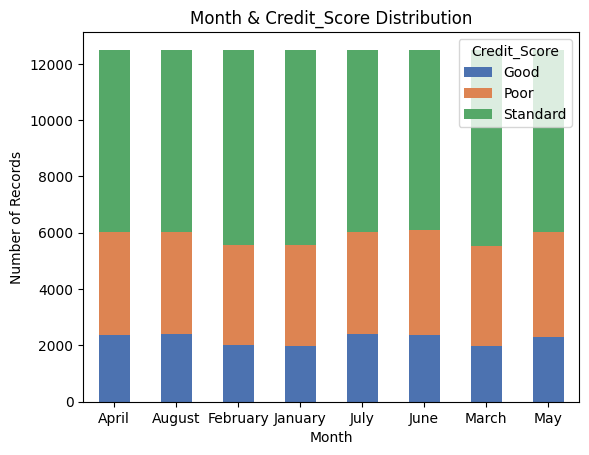

In [212]:
get_column_details(df_train,'Month')

plot_stacked_bar(df_train,'Month','Credit_Score')

In [213]:
df_train['Month'] = pd.to_datetime(df_train.Month, format='%B').dt.month

In [214]:
get_column_details(df_train,'Name')

Details of Name column

DataType:  object

There are  9985  null values

Number of Unique Values:  10139

Distribution of column:

Name
Stevex                44
Langep                44
Vaughanl              39
Jessicad              39
Deepa Seetharamanm    38
                      ..
Bavierq                4
Alina Selyukhg         4
Janeman Latulf         4
Lucye                  4
Timothyl               3
Name: count, Length: 10139, dtype: int64


Видим, что у нас есть много пропущенных имен, исправим:

In [215]:
clean_categorical_field(df_train,'Customer_ID','Name')

In [216]:
garbage_value = '#F%$D@*&8'

get_column_details(df_train,'SSN')

clean_categorical_field(df_train,'Customer_ID','SSN',garbage_value)

Details of SSN column

DataType:  object

There are  0  null values

Number of Unique Values:  12501

Distribution of column:

SSN
#F%$D@*&8      5572
940-15-4402       8
571-35-3463       8
422-50-2476       8
430-60-9262       8
               ... 
604-62-6133       4
331-28-1921       4
838-33-4811       4
856-06-6147       4
753-72-2651       4
Name: count, Length: 12501, dtype: int64


In [217]:
get_column_details(df_train,'SSN')

Details of SSN column

DataType:  object

There are  0  null values

Number of Unique Values:  12500

Distribution of column:

SSN
078-73-5990    8
821-00-0265    8
004-07-5839    8
486-85-3974    8
061-64-3430    8
              ..
070-19-1622    8
500-92-6408    8
411-51-0676    8
612-70-8987    8
615-06-7821    8
Name: count, Length: 12500, dtype: int64


Details of Occupation column

DataType:  object

There are  0  null values

Number of Unique Values:  16

Distribution of column:

Occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64

Occupation & Credit_Score Distribution


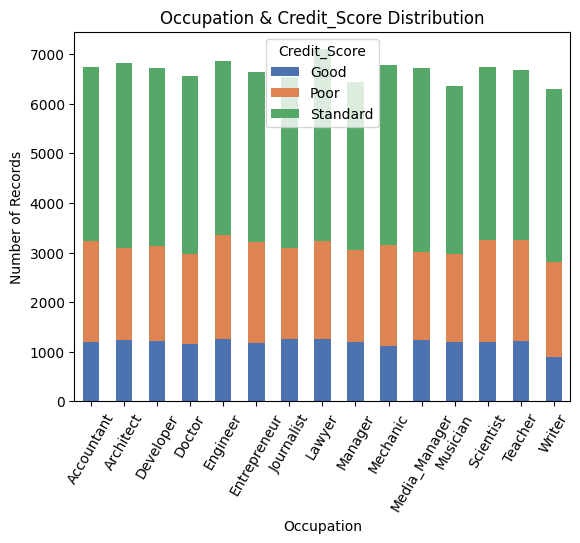

In [218]:
get_column_details(df_train,'Occupation')

clean_categorical_field(df_train,'Customer_ID','Occupation','_______')

plot_stacked_bar(df_train,'Occupation','Credit_Score',rotation=60)

In [219]:
get_column_details(df_train,'Type_of_Loan')

Details of Type_of_Loan column

DataType:  object

There are  11408  null values

Number of Unique Values:  6260

Distribution of column:

Type_of_Loan
Not Specified                                                                                                                    1408
Credit-Builder Loan                                                                                                              1280
Personal Loan                                                                                                                    1272
Debt Consolidation Loan                                                                                                          1264
Student Loan                                                                                                                     1240
                                                                                                                                 ... 
Debt Consolidation Loan, Personal Loan, Mort

In [220]:
df_train['Type_of_Loan'].replace([np.nan], 'Not Specified', inplace=True)

/tmp/ipykernel_55700/1160556289.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Type_of_Loan'].replace([np.nan], 'Not Specified', inplace=True)


In [221]:
get_column_details(df_train,'Credit_Mix')

Details of Credit_Mix column

DataType:  object

There are  0  null values

Number of Unique Values:  4

Distribution of column:

Credit_Mix
Standard    36479
Good        24337
_           20195
Bad         18989
Name: count, dtype: int64



Credit_Mix & Credit_Score Distribution


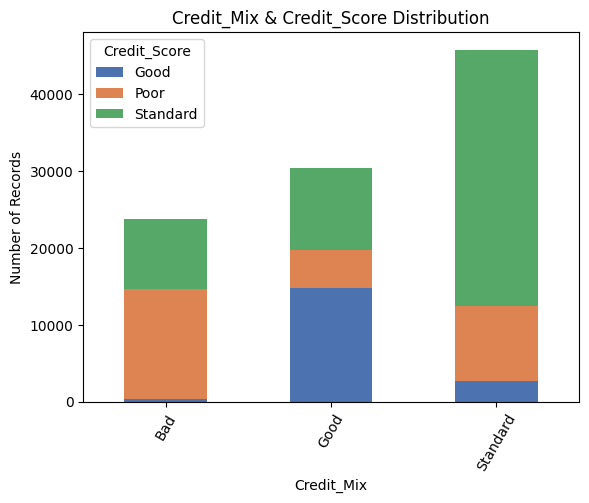

In [222]:
clean_categorical_field(df_train,'Customer_ID','Credit_Mix','_')

plot_stacked_bar(df_train,'Credit_Mix','Credit_Score',rotation=60)

In [223]:
get_column_details(df_train,'Payment_of_Min_Amount')

Details of Payment_of_Min_Amount column

DataType:  object

There are  0  null values

Number of Unique Values:  3

Distribution of column:

Payment_of_Min_Amount
Yes    52326
No     35667
NM     12007
Name: count, dtype: int64


In [224]:
get_column_details(df_train,'Payment_Behaviour')

Details of Payment_Behaviour column

DataType:  object

There are  0  null values

Number of Unique Values:  7

Distribution of column:

Payment_Behaviour
Low_spent_Small_value_payments      25513
High_spent_Medium_value_payments    17540
Low_spent_Medium_value_payments     13861
High_spent_Large_value_payments     13721
High_spent_Small_value_payments     11340
Low_spent_Large_value_payments      10425
!@9#%8                               7600
Name: count, dtype: int64


Details of Payment_Behaviour column

DataType:  object

There are  0  null values

Number of Unique Values:  6

Distribution of column:

Payment_Behaviour
Low_spent_Small_value_payments      27767
High_spent_Medium_value_payments    19366
High_spent_Large_value_payments     15348
Low_spent_Medium_value_payments     14621
High_spent_Small_value_payments     11980
Low_spent_Large_value_payments      10918
Name: count, dtype: int64

Payment_Behaviour & Credit_Score Distribution


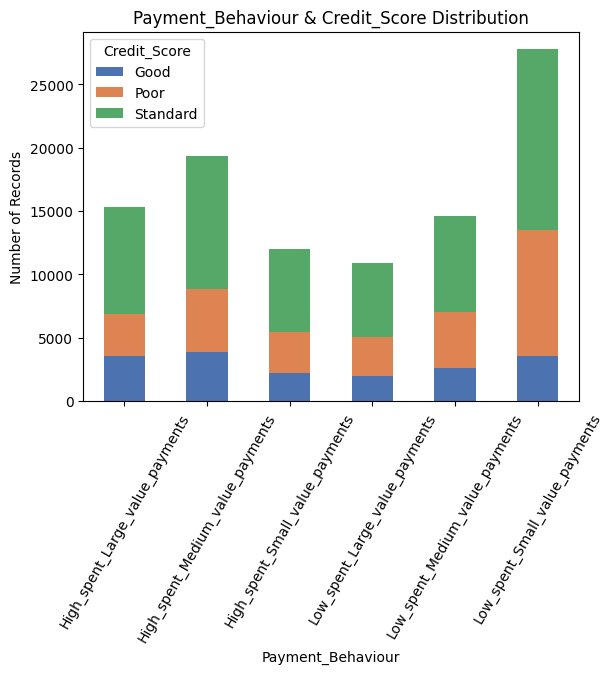

In [225]:
clean_categorical_field(df_train,'Customer_ID','Payment_Behaviour','!@9#%8')

get_column_details(df_train,'Payment_Behaviour')

plot_stacked_bar(df_train,'Payment_Behaviour','Credit_Score',rotation=60)

In [226]:
get_column_details(df_train,'Credit_Score')

Details of Credit_Score column

DataType:  object

There are  0  null values

Number of Unique Values:  3

Distribution of column:

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


Details of Credit_Score column

DataType:  object

There are  0  null values

Number of Unique Values:  3

Distribution of column:

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

Credit Score Distribution


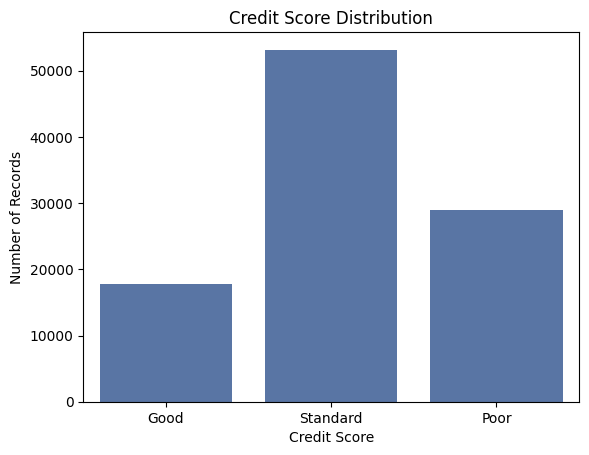

In [227]:
get_column_details(df_train,'Credit_Score')

plot_countplot(df_train,'Credit_Score','Credit Score')

Теперь посмотрим на числовые признаки

Details of Age column

DataType:  object

There are  0  null values

Number of Unique Values:  1788

Distribution of column:

Age
38      2833
28      2829
31      2806
26      2792
32      2749
        ... 
6618       1
3155       1
5063       1
2875       1
4347       1
Name: count, Length: 1788, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Age Distribution


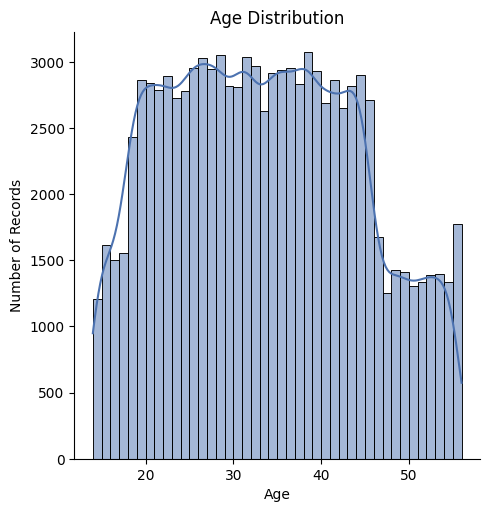

In [228]:
get_column_details(df_train,'Age')

clean_numerical_field(df_train,'Customer_ID','Age',strip='_',datatype='int')

plot_displot(df_train,'Age','Age',bins=42)

Details of Annual_Income column

DataType:  object

There are  0  null values

Number of Unique Values:  18940

Distribution of column:

Annual_Income
36585.12     16
20867.67     16
17273.83     16
95596.35     15
33029.66     15
             ..
3917169.0     1
89394.78_     1
36806.84_     1
24363.78_     1
95685.21_     1
Name: count, Length: 18940, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Annual Income Distribution


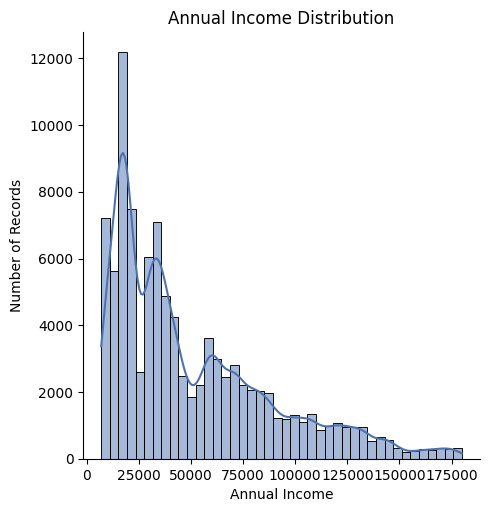

In [229]:
get_column_details(df_train,'Annual_Income')

clean_numerical_field(df_train,'Customer_ID','Annual_Income',strip='_',datatype='float')

plot_displot(df_train,'Annual_Income','Annual Income',bins=42)

Details of Monthly_Inhand_Salary column

DataType:  float64

There are  15002  null values

Number of Unique Values:  13235

Distribution of column:

Monthly_Inhand_Salary
2295.058333    15
6082.187500    15
6358.956667    15
6769.130000    15
3080.555000    14
               ..
3415.781667     1
6272.739429     1
1069.950000     1
454.382083      1
2319.831269     1
Name: count, Length: 13235, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Monthly Inhand Salary Distribution


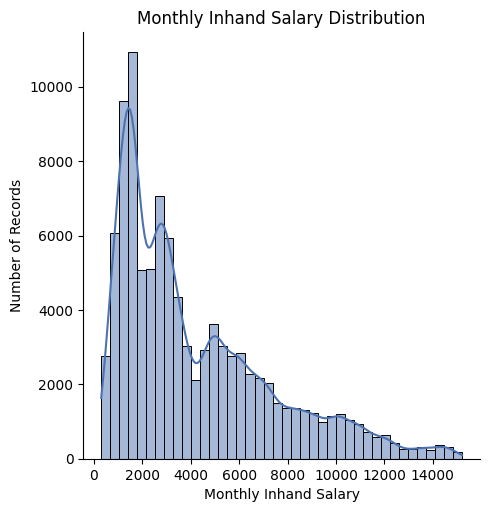

In [230]:
get_column_details(df_train,'Monthly_Inhand_Salary')

clean_numerical_field(df_train,'Customer_ID','Monthly_Inhand_Salary')

plot_displot(df_train,'Monthly_Inhand_Salary','Monthly Inhand Salary',bins=40)

Details of Num_Bank_Accounts column

DataType:  int64

There are  0  null values

Number of Unique Values:  943

Distribution of column:

Num_Bank_Accounts
6       13001
7       12823
8       12765
4       12186
5       12118
        ...  
1091        1
1123        1
1657        1
299         1
1240        1
Name: count, Length: 943, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Num_Bank_Accounts Distribution


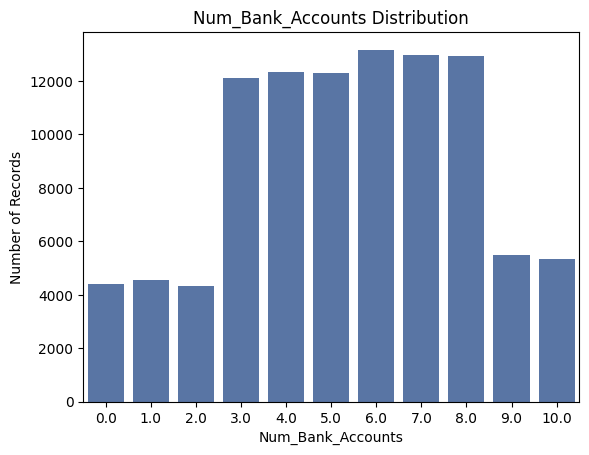

In [231]:
column_name = 'Num_Bank_Accounts'

get_column_details(df_train,column_name)

clean_numerical_field(df_train,'Customer_ID',column_name)

plot_countplot(df_train,column_name,column_name)

Details of Num_Credit_Card column

DataType:  int64

There are  0  null values

Number of Unique Values:  1179

Distribution of column:

Num_Credit_Card
5       18459
7       16615
6       16559
4       14030
3       13277
        ...  
1405        1
708         1
62          1
343         1
481         1
Name: count, Length: 1179, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Num_Credit_Card Distribution


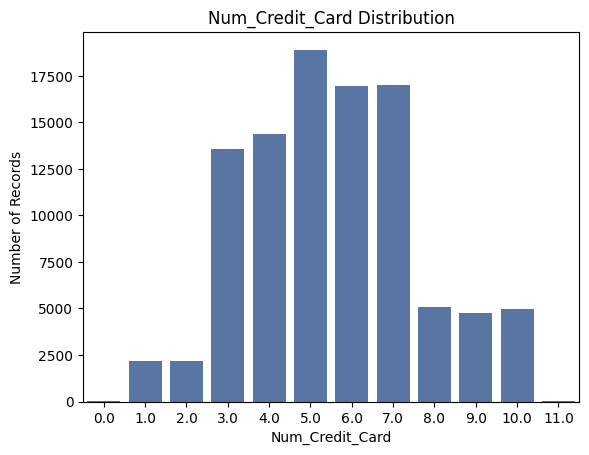

In [232]:
column_name = 'Num_Credit_Card'

get_column_details(df_train,column_name)

clean_numerical_field(df_train,'Customer_ID',column_name)

plot_countplot(df_train,column_name,column_name)

Details of Interest_Rate column

DataType:  int64

There are  0  null values

Number of Unique Values:  1750

Distribution of column:

Interest_Rate
8       5012
5       4979
6       4721
10      4540
12      4540
        ... 
2548       1
967        1
3790       1
3782       1
4372       1
Name: count, Length: 1750, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Interest_Rate Distribution


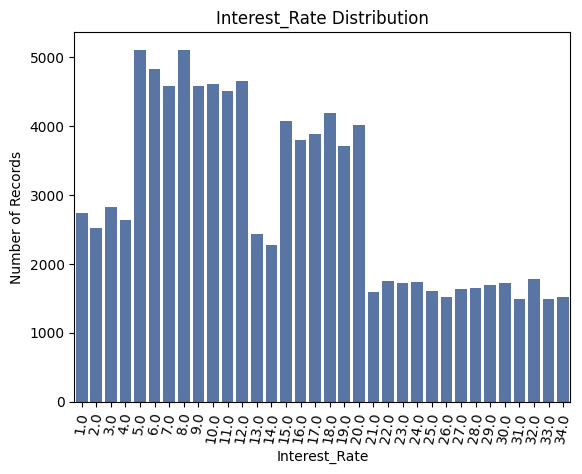

In [233]:
column_name = 'Interest_Rate'

get_column_details(df_train,column_name)

clean_numerical_field(df_train,'Customer_ID',column_name)

plot_countplot(df_train,column_name,column_name,rotation=80)

Details of Delay_from_due_date column

DataType:  int64

There are  0  null values

Number of Unique Values:  73

Distribution of column:

Delay_from_due_date
 15    3596
 13    3424
 8     3324
 14    3313
 10    3281
       ... 
-4       62
 65      56
-5       33
 66      32
 67      22
Name: count, Length: 73, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Delay_from_due_date Distribution


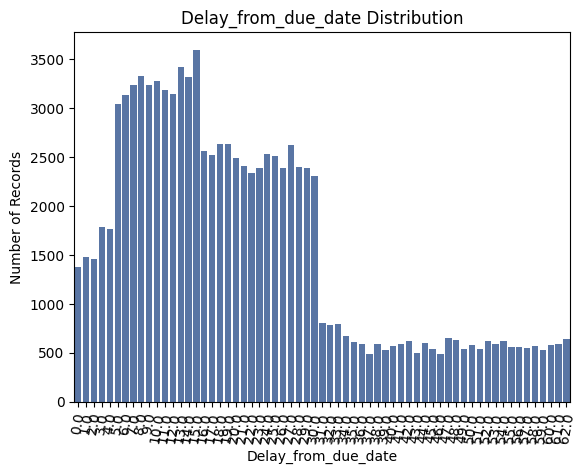

In [234]:
column_name = 'Delay_from_due_date'

get_column_details(df_train,column_name)

clean_numerical_field(df_train,'Customer_ID',column_name)

plot_countplot(df_train,column_name,column_name,rotation=80)

Details of Num_of_Delayed_Payment column

DataType:  object

There are  7002  null values

Number of Unique Values:  749

Distribution of column:

Num_of_Delayed_Payment
19      5327
17      5261
16      5173
10      5153
18      5083
        ... 
3845       1
4075       1
1502       1
1530       1
3011       1
Name: count, Length: 749, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Num_of_Delayed_Payment Distribution


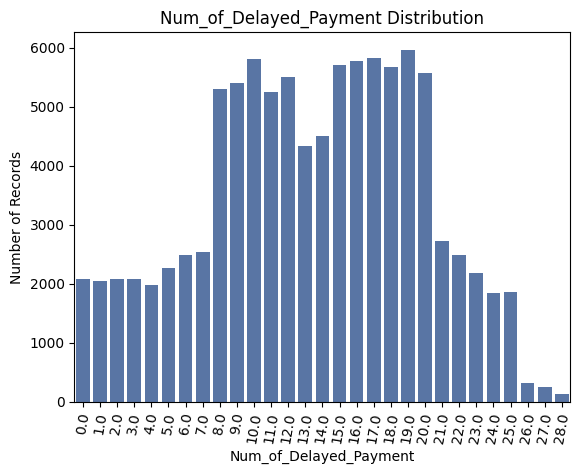

In [235]:
column_name = 'Num_of_Delayed_Payment'

get_column_details(df_train,column_name)

clean_numerical_field(df_train,'Customer_ID',column_name,strip='_',datatype='float')

plot_countplot(df_train,column_name,column_name,rotation=80)

Details of Changed_Credit_Limit column

DataType:  object

There are  0  null values

Number of Unique Values:  4384

Distribution of column:

Changed_Credit_Limit
_                    2091
8.22                  133
11.5                  127
11.32                 126
7.35                  121
                     ... 
30.16                   1
4.710000000000001       1
-4.39                   1
27.38                   1
16.63                   1
Name: count, Length: 4384, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Changed_Credit_Limit Distribution


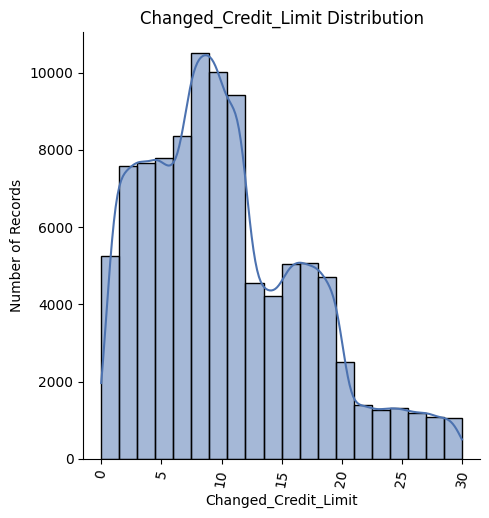

In [236]:
column_name = 'Changed_Credit_Limit'

get_column_details(df_train,column_name)

clean_numerical_field(df_train,'Customer_ID',column_name,strip='_',datatype='float')

plot_displot(df_train,column_name,column_name,rotation=80)

Details of Num_Credit_Inquiries column

DataType:  float64

There are  1965  null values

Number of Unique Values:  1223

Distribution of column:

Num_Credit_Inquiries
4.0       11271
3.0        8890
6.0        8111
7.0        8058
2.0        8028
          ...  
1618.0        1
758.0         1
735.0         1
2483.0        1
1960.0        1
Name: count, Length: 1223, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Num_Credit_Inquiries Distribution


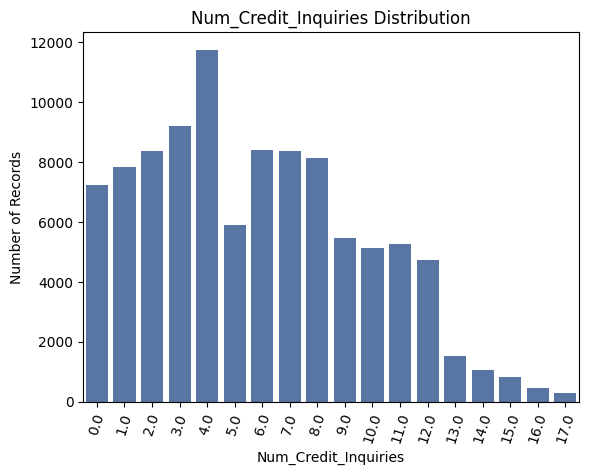

In [237]:
column_name = 'Num_Credit_Inquiries'

get_column_details(df_train,column_name)

clean_numerical_field(df_train,'Customer_ID',column_name)

plot_countplot(df_train,column_name,column_name,rotation=72)

Details of Outstanding_Debt column

DataType:  object

There are  0  null values

Number of Unique Values:  13178

Distribution of column:

Outstanding_Debt
1360.45     24
1151.7      23
460.46      23
1109.03     23
1329.59     16
            ..
1619.56_     1
297.64_      1
1264.42_     1
1617.55_     1
1324.1_      1
Name: count, Length: 13178, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Outstanding_Debt Distribution


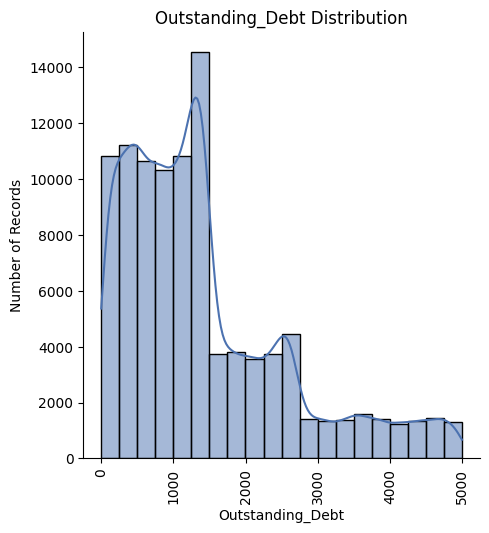

In [238]:
column_name = 'Outstanding_Debt'

get_column_details(df_train,column_name)

clean_numerical_field(df_train,'Customer_ID',column_name,strip='_',datatype=float)

plot_displot(df_train,column_name,column_name,rotation=90)


Details of Credit_Utilization_Ratio column

DataType:  float64

There are  0  null values

Number of Unique Values:  100000

Distribution of column:

Credit_Utilization_Ratio
39.300980    1
38.850680    1
37.753013    1
27.495263    1
36.979007    1
            ..
24.797347    1
31.377862    1
28.609352    1
31.944960    1
26.822620    1
Name: count, Length: 100000, dtype: int64

Credit_Utilization_Ratio Distribution


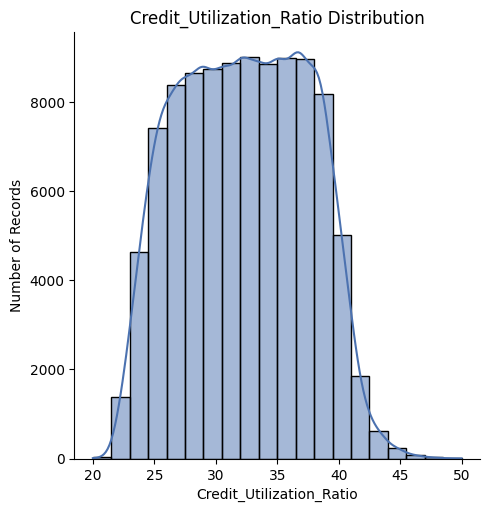

In [239]:
column_name = 'Credit_Utilization_Ratio'

get_column_details(df_train,column_name)

plot_displot(df_train,column_name,column_name)

In [240]:
def Month_Converter(val):
    if pd.notnull(val):
        years = int(val.split(' ')[0])
        month = int(val.split(' ')[3])
        return (years * 12) + month
    else:
        return val

df_train['Credit_History_Age'] = df_train['Credit_History_Age'].apply(lambda x: Month_Converter(x)).astype(float)

Details of Credit_History_Age column

DataType:  float64

There are  9030  null values

Number of Unique Values:  404

Distribution of column:

Credit_History_Age
191.0    446
232.0    445
233.0    444
215.0    443
231.0    441
        ... 
3.0       20
2.0       15
403.0     14
404.0     12
1.0        2
Name: count, Length: 404, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Credit_History_Age Distribution


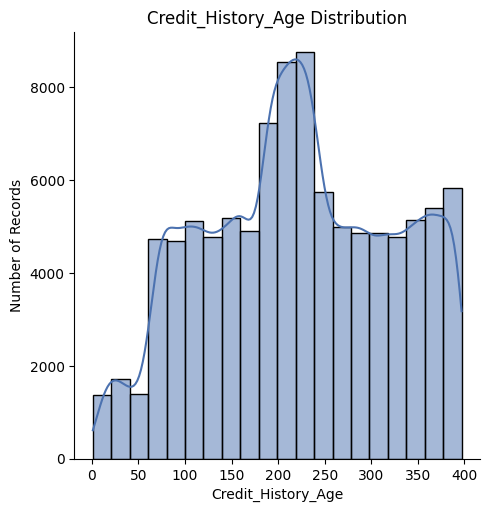

In [241]:
column_name = 'Credit_History_Age'

get_column_details(df_train,column_name)

clean_numerical_field(df_train,'Customer_ID',column_name,datatype=float)

plot_displot(df_train,column_name,column_name)

Details of Total_EMI_per_month column

DataType:  float64

There are  0  null values

Number of Unique Values:  14950

Distribution of column:

Total_EMI_per_month
0.000000        10613
135.133799          8
182.585183          8
427.144183          8
83.829111           8
                ...  
33746.000000        1
39347.000000        1
27292.000000        1
16627.000000        1
49430.000000        1
Name: count, Length: 14950, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Total_EMI_per_month Distribution


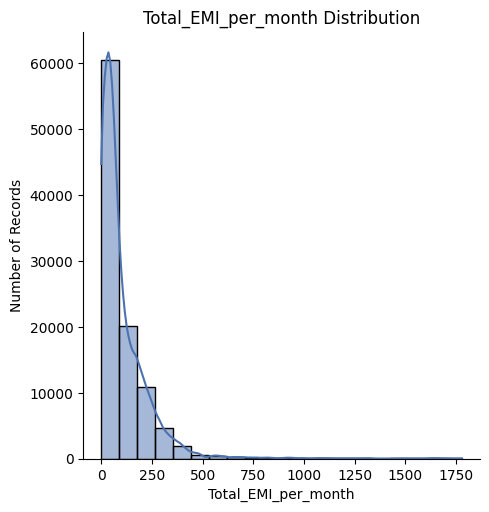

In [242]:
column_name = 'Total_EMI_per_month'

get_column_details(df_train,column_name)

clean_numerical_field(df_train,'Customer_ID',column_name,datatype=float)

plot_displot(df_train,column_name,column_name)

Details of Amount_invested_monthly column

DataType:  object

There are  4479  null values

Number of Unique Values:  91049

Distribution of column:

Amount_invested_monthly
__10000__             4305
0.0                    169
59.93725850034815        1
165.180659491917         1
62.030802602004044       1
                      ... 
109.296681189146         1
33.6098814431885         1
76.87001005130772        1
908.6939096189257        1
401.35900899207513       1
Name: count, Length: 91049, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Amount_invested_monthly Distribution


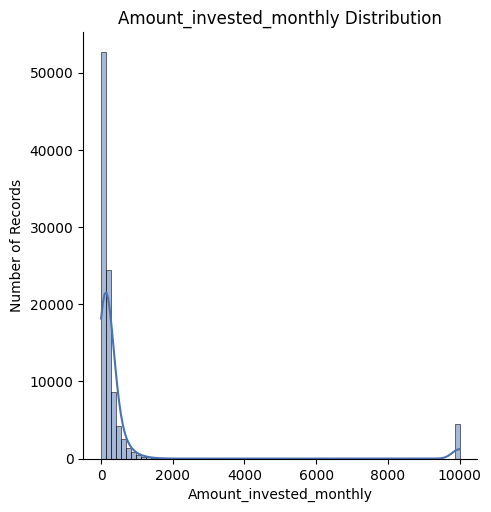

In [243]:
column_name = 'Amount_invested_monthly'

get_column_details(df_train,column_name)

clean_numerical_field(df_train,'Customer_ID',column_name,datatype=float,strip='_')

plot_displot(df_train,column_name,column_name,bins=72)

Details of Monthly_Balance column

DataType:  object

There are  1200  null values

Number of Unique Values:  98792

Distribution of column:

Monthly_Balance
__-333333333333333333333333333__    9
252.08489793906085                  1
254.9709216273975                   1
250.0931678204641                   1
289.7550752754317                   1
                                   ..
278.8720257394474                   1
376.7024623690405                   1
321.2336043357731                   1
373.29270287694055                  1
336.6371802877606                   1
Name: count, Length: 98792, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Monthly_Balance Distribution


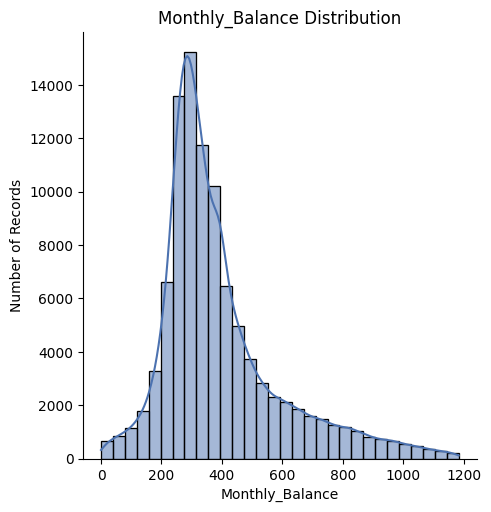

In [244]:
column_name = 'Monthly_Balance'

get_column_details(df_train,column_name)

df_train[column_name].replace('',np.nan)
clean_numerical_field(df_train,'Customer_ID',column_name,strip='_',datatype=float,replace_value='__-333333333333333333333333333__')

plot_displot(df_train,column_name,column_name,bins=30)

Details of Num_of_Loan column

DataType:  object

There are  0  null values

Number of Unique Values:  434

Distribution of column:

Num_of_Loan
3      14386
2      14250
4      14016
0      10380
1      10083
       ...  
41         1
18         1
56         1
657        1
917        1
Name: count, Length: 434, dtype: int64


/tmp/ipykernel_55700/2322746903.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)



Num_of_Loan Distribution


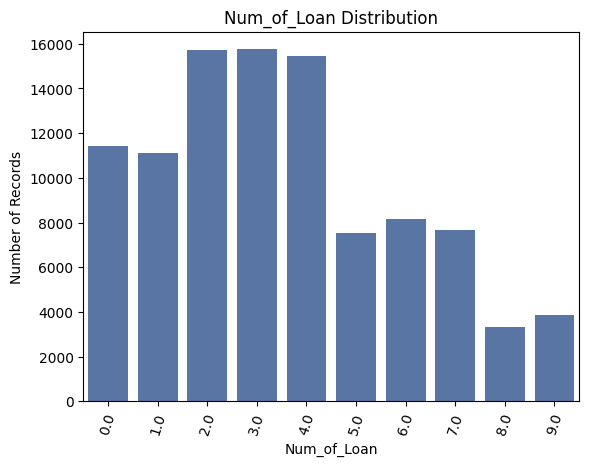

In [245]:
column_name = 'Num_of_Loan'

get_column_details(df_train,column_name)

clean_numerical_field(df_train,'Customer_ID',column_name,strip='_',datatype=float)

plot_countplot(df_train,column_name,column_name,rotation=72)

In [246]:
df_train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [247]:
drop_columns = ['ID','Customer_ID','Name','SSN']
df_train.drop(drop_columns,axis=1,inplace=True)
df_train.shape

(100000, 24)

In [266]:
df_clean = df_train.copy()

df_enc = df_clean.copy()

df_cat = df_clean.copy()

In [267]:
le_target = LabelEncoder()
df_enc['Credit_Score'] = le_target.fit_transform(df_enc['Credit_Score'])

le_loan = LabelEncoder()
df_enc['Type_of_Loan'] = le_loan.fit_transform(df_enc['Type_of_Loan'])

low_cardinality_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
df_enc = pd.get_dummies(df_enc, columns=low_cardinality_cols, prefix=low_cardinality_cols)

X_enc = df_enc.drop('Credit_Score', axis=1)
y_enc = df_enc['Credit_Score']
scaler = StandardScaler()
X_enc = scaler.fit_transform(X_enc)

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(X_enc, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

In [268]:
df_cat['Credit_Score'] = le_target.transform(df_cat['Credit_Score'])

X_cat = df_cat.drop('Credit_Score', axis=1)
y_cat = df_cat['Credit_Score']

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

cat_features = X_train_cat.select_dtypes(include=['object']).columns.tolist()

In [251]:
classifiers = [
    ('Decision Tree', DecisionTreeClassifier()),
    ('Random Forest', RandomForestClassifier()),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('XGB', XGBClassifier()),
]

for clf_name, clf in classifiers:
    avg_accuracy =  cross_val_score(clf, X_train_enc, y_train_enc, cv=5, scoring='accuracy').mean()
    avg_precision = cross_val_score(clf, X_train_enc, y_train_enc, cv=5, scoring='precision_macro').mean()
    avg_recall = cross_val_score(clf, X_train_enc, y_train_enc, cv=5, scoring='recall_macro').mean()

    print(f'Classifier: {clf_name}')
    print(f'Average Accuracy: {avg_accuracy:.4f}')
    print(f'Average Precision: {avg_precision:.4f}')
    print(f'Average Recall: {avg_recall:.4f}')

Classifier: Decision Tree
Average Accuracy: 0.7250
Average Precision: 0.7079
Average Recall: 0.7094
Classifier: Random Forest
Average Accuracy: 0.8134
Average Precision: 0.8013
Average Recall: 0.8067
Classifier: KNN
Average Accuracy: 0.6721
Average Precision: 0.6433
Average Recall: 0.6492
Classifier: XGB
Average Accuracy: 0.7741
Average Precision: 0.7582
Average Recall: 0.7647


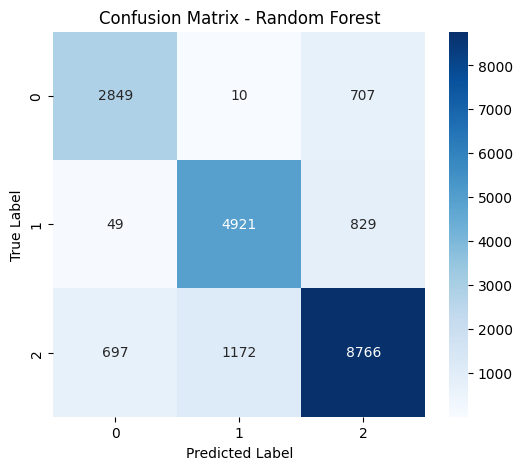

In [258]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(X_train_enc, y_train_enc)

y_pred = rf_classifier.predict(X_test_enc)
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_classifier.classes_,
            yticklabels=rf_classifier.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [259]:
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred, target_names=['Poor', 'Standard', 'Good']))


Classification Report:
              precision    recall  f1-score   support

        Poor       0.79      0.80      0.80      3566
    Standard       0.81      0.85      0.83      5799
        Good       0.85      0.82      0.84     10635

    accuracy                           0.83     20000
   macro avg       0.82      0.82      0.82     20000
weighted avg       0.83      0.83      0.83     20000



In [271]:
model = CatBoostClassifier()
model.fit(
    X_train_cat, y_train_cat,
    cat_features=cat_features,
    verbose=False
)

CatBoostClassifier()

In [272]:
y_pred = model.predict(X_test_cat)


accuracy = accuracy_score(y_test_cat, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test_cat, y_pred))

Accuracy: 0.8221
              precision    recall  f1-score   support

           0       0.74      0.84      0.79      3566
           1       0.80      0.86      0.83      5799
           2       0.87      0.79      0.83     10635

    accuracy                           0.82     20000
   macro avg       0.80      0.83      0.82     20000
weighted avg       0.83      0.82      0.82     20000



Для улучшения точности можно использовать SMOTE, чтобы сбалансировать классы и получить более точные предсказания.

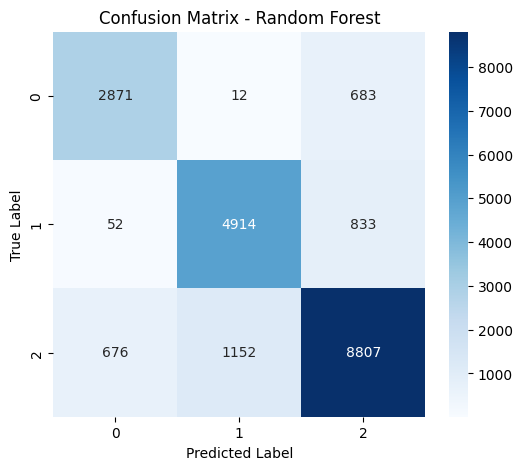

In [275]:
rf_classifier = RandomForestClassifier(n_estimators=128, random_state=42)

rf_classifier.fit(X_train_enc, y_train_enc)

y_pred = rf_classifier.predict(X_test_enc)
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_classifier.classes_,
            yticklabels=rf_classifier.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [276]:
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred, target_names=['Poor', 'Standard', 'Good']))


Classification Report:
              precision    recall  f1-score   support

        Poor       0.80      0.81      0.80      3566
    Standard       0.81      0.85      0.83      5799
        Good       0.85      0.83      0.84     10635

    accuracy                           0.83     20000
   macro avg       0.82      0.83      0.82     20000
weighted avg       0.83      0.83      0.83     20000



**Итоги.**

Мы увидели, что random forest и catboost дают очень хорошие результаты, catboost немного уступает, но только по причине того что датасет имеет сильный дисбаланс классов.

В целом результат вышел очень хороший, accuracy 0.83, это радует

